# Results Analysis

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
REPO_ROOT = Path('..').resolve()
DATA = REPO_ROOT / 'data'
RNG_SEED = 42

pd.options.display.float_format = '{:.3f}'.format
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

METRIC_COLS = ['keyword_hit_rate', 'judge_correctness', 'judge_faithfulness', 'judge_helpfulness']
METRIC_LABELS = {'keyword_hit_rate': 'KHR', 'judge_correctness': 'Correctness', 'judge_faithfulness': 'Faithfulness', 'judge_helpfulness': 'Helpfulness'}

RG_DIVERGING = LinearSegmentedColormap.from_list('rg', ['#c0392b', '#f5f5f5', '#27ae60'], N=256)

## Load the three judged result CSVs

In [4]:
csv_paths = {
    'v1': DATA / 'eval_results_v1_44q_judged.csv',
    'v2': DATA / 'eval_results_v2_websnoise.csv',
    'v3': DATA / 'eval_results_v3_judged.csv',
}
dfs = {}
for label, path in csv_paths.items():
    if path.exists():
        dfs[label] = pd.read_csv(path)
        print(f'{label}: {len(dfs[label])} rows ({path.name})')
    else:
        print(f'{label}: MISSING at {path.name}')
VERSIONS = list(dfs.keys())
CONDITIONS = ['baseline_no_tables', 'baseline_tables', 'crag_no_tables', 'crag_tables']

v1: 176 rows (eval_results_v1_44q_judged.csv)
v2: 176 rows (eval_results_v2_websnoise.csv)
v3: 176 rows (eval_results_v3_judged.csv)


In [5]:
rows = []
for v, df in dfs.items():
    for cond in CONDITIONS:
        sub = df[df['condition'] == cond]
        row = {'version': v, 'condition': cond}
        for m in METRIC_COLS:
            row[METRIC_LABELS[m]] = sub[m].mean() if m in sub.columns else None
        row['Latency (s)'] = sub['latency_ms'].mean() / 1000 if 'latency_ms' in sub.columns else None
        rows.append(row)
summary = pd.DataFrame(rows).set_index(['condition', 'version'])
summary.round(3)

,,KHR,Correctness,Faithfulness,Helpfulness,Latency (s)
condition,version,,,,,
baseline_no_tables,v1,0.677,0.757,0.755,0.786,4.173
baseline_tables,v1,0.668,0.691,0.645,0.709,4.489
crag_no_tables,v1,0.759,0.666,0.614,0.730,8.226
crag_tables,v1,0.700,0.691,0.680,0.757,10.749
baseline_no_tables,v2,0.677,0.775,0.691,0.834,5.997
baseline_tables,v2,0.677,0.675,0.630,0.707,4.727
crag_no_tables,v2,0.750,0.661,0.636,0.723,15.098
crag_tables,v2,0.727,0.652,0.611,0.668,17.883
baseline_no_tables,v3,0.668,0.782,0.745,0.816,5.677


## Heatmap

Three small heatmaps: v2 − v1, v3 − v2, v3 − v1. Green = improved, red = regressed.

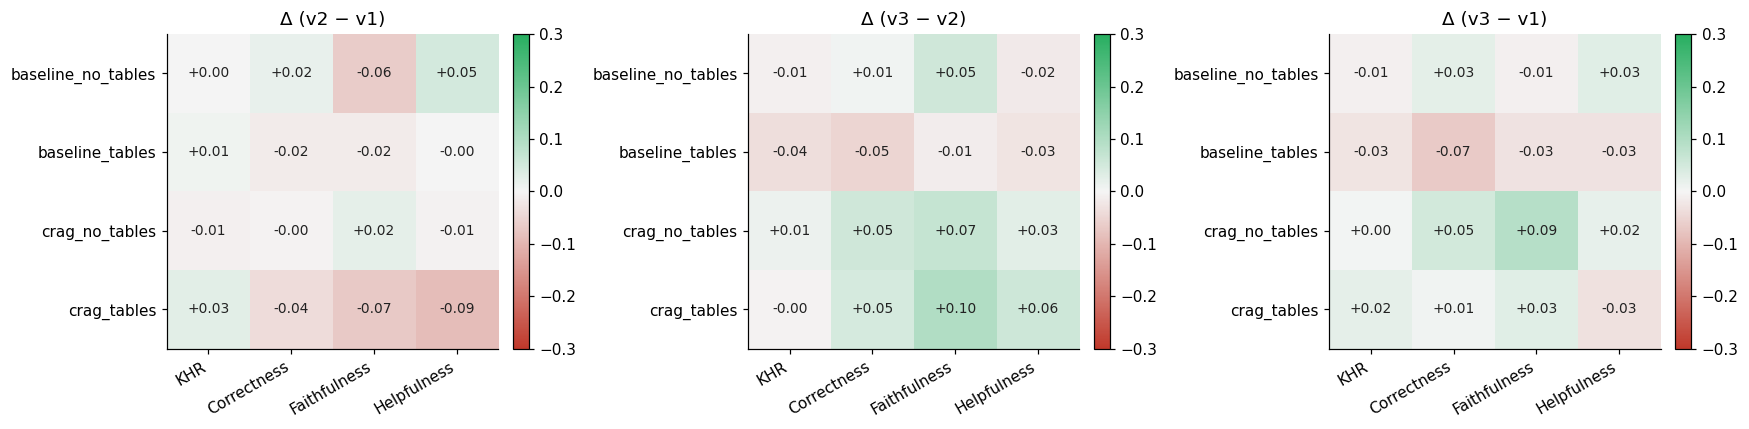

In [6]:
def deltas_between(v_a, v_b, dfs):
    result = []
    for cond in CONDITIONS:
        a = dfs[v_a][dfs[v_a]['condition'] == cond]
        b = dfs[v_b][dfs[v_b]['condition'] == cond]
        row = {'condition': cond}
        for m in METRIC_COLS:
            if m in a.columns and m in b.columns:
                row[METRIC_LABELS[m]] = b[m].mean() - a[m].mean()
        result.append(row)
    return pd.DataFrame(result).set_index('condition')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (label, (a, b)) in zip(axes, [('v2 − v1', ('v1', 'v2')),
                                       ('v3 − v2', ('v2', 'v3')),
                                       ('v3 − v1', ('v1', 'v3'))]):
    if a in dfs and b in dfs:
        delta = deltas_between(a, b, dfs)
        im = ax.imshow(delta.values, cmap=RG_DIVERGING, vmin=-0.3, vmax=0.3, aspect='auto')
        ax.set_xticks(range(len(delta.columns)))
        ax.set_xticklabels(delta.columns, rotation=30, ha='right')
        ax.set_yticks(range(len(delta.index)))
        ax.set_yticklabels(delta.index)
        ax.set_title(f'Δ ({label})')
        for i in range(len(delta.index)):
            for j in range(len(delta.columns)):
                v = delta.values[i, j]
                ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                        color='white' if abs(v) > 0.18 else '#222', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 4. Slope graphs

/var/folders/dz/ykmlvvnx7gg2p91fhyn9gn600000gn/T/ipykernel_70957/4115178758.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


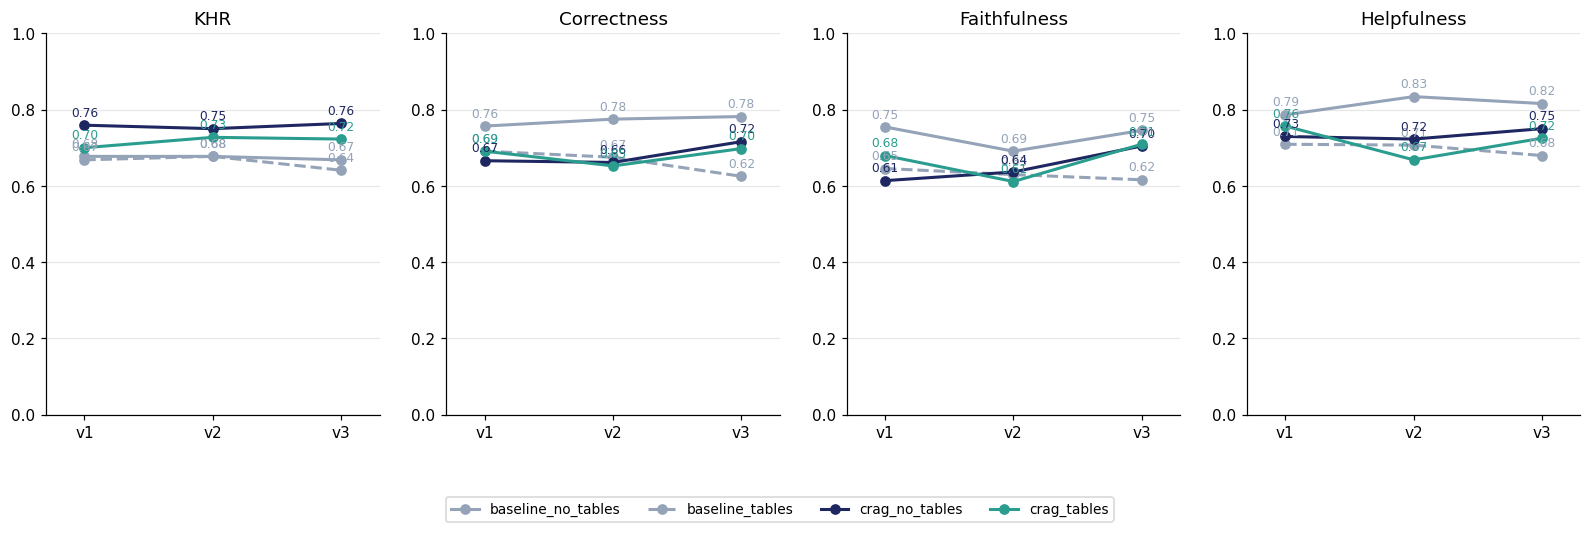

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=False)
cond_colors = {'baseline_no_tables': '#94A3B8', 'baseline_tables': '#94A3B8', 'crag_no_tables': '#1E2761', 'crag_tables': '#2A9D8F'}
cond_styles = {'baseline_no_tables': '-', 'baseline_tables': '--', 'crag_no_tables': '-', 'crag_tables': '-'}
for ax, m in zip(axes, METRIC_COLS):
    label = METRIC_LABELS[m]
    for cond in CONDITIONS:
        ys = []
        for v in VERSIONS:
            df = dfs[v]
            sub = df[df['condition'] == cond]
            ys.append(sub[m].mean() if m in sub.columns else float('nan'))
        ax.plot(VERSIONS, ys, marker='o', linewidth=2,
                color=cond_colors[cond], linestyle=cond_styles[cond], label=cond)
        for x, y in zip(VERSIONS, ys):
            if not np.isnan(y):
                ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                            xytext=(0, 6), ha='center', fontsize=8, color=cond_colors[cond])
    ax.set_title(label)
    ax.set_xlim(-0.3, 2.3)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
axes[0].legend(loc='lower center', bbox_to_anchor=(2.2, -0.3), ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

## Diverging bar chart

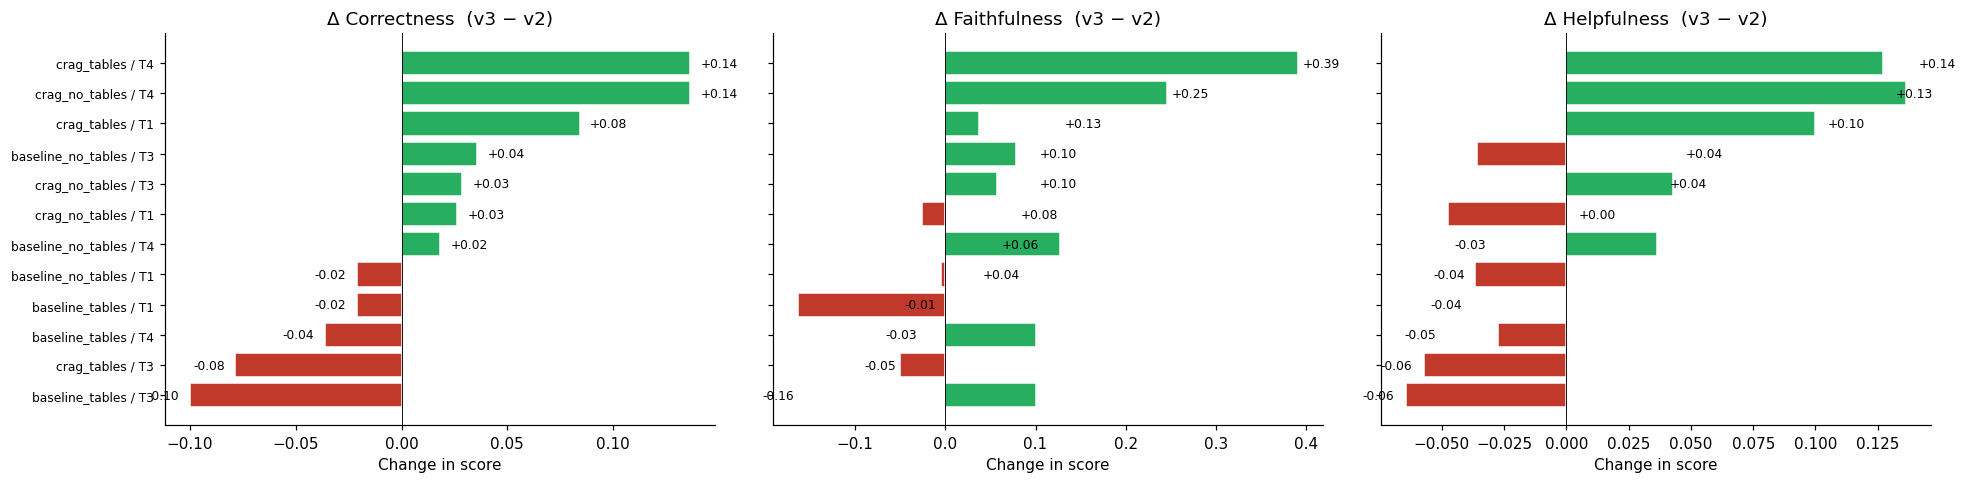

In [8]:
if 'v2' in dfs and 'v3' in dfs and 'judge_correctness' in dfs['v3'].columns:
    rows = []
    for cond in CONDITIONS:
        for qt in sorted(dfs['v3']['question_type'].unique()):
            for m in ['judge_correctness', 'judge_faithfulness', 'judge_helpfulness']:
                a = dfs['v2'][(dfs['v2']['condition']==cond) & (dfs['v2']['question_type']==qt)]
                b = dfs['v3'][(dfs['v3']['condition']==cond) & (dfs['v3']['question_type']==qt)]
                if m in a.columns and m in b.columns and len(a) and len(b):
                    rows.append({'condition': cond, 'question_type': qt,
                                 'metric': METRIC_LABELS[m], 'delta': b[m].mean() - a[m].mean()})
    delta_df = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
    for ax, metric in zip(axes, ['Correctness', 'Faithfulness', 'Helpfulness']):
        sub = delta_df[delta_df['metric'] == metric].copy()
        sub['label'] = sub['condition'] + ' / T' + sub['question_type'].astype(str)
        sub = sub.sort_values('delta')
        colors = ['#27ae60' if d >= 0 else '#c0392b' for d in sub['delta']]
        ax.barh(sub['label'], sub['delta'], color=colors, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.6)
        ax.set_title(f'Δ {metric}  (v3 − v2)')
        ax.set_xlabel('Change in score')
        ax.tick_params(axis='y', labelsize=8)
        for i, (_, row) in enumerate(sub.iterrows()):
            d = row['delta']
            ax.text(d + (0.005 if d >= 0 else -0.005), i, f'{d:+.2f}',
                    ha='left' if d >= 0 else 'right', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

## KHR vs judge-correctness — does KHR predict the judge?

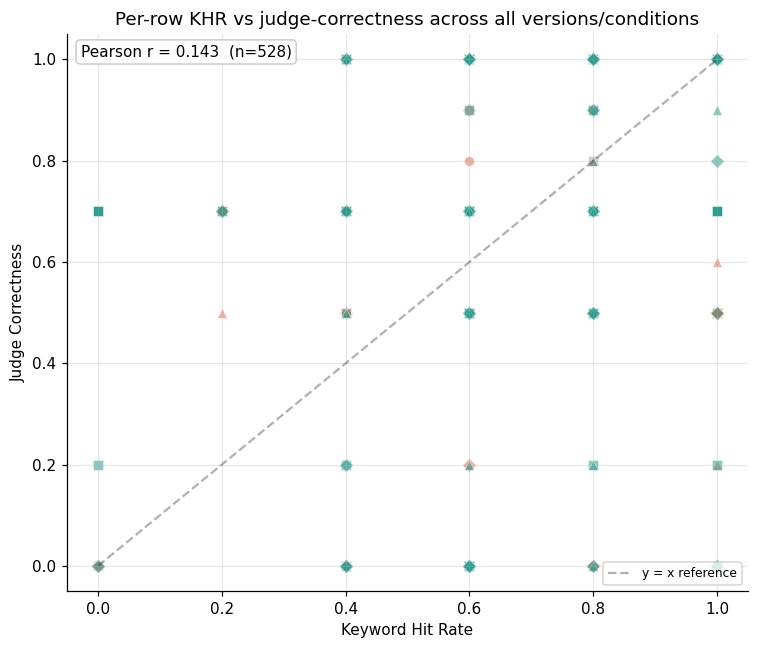

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
version_colors = {'v1': '#94A3B8', 'v2': '#E76F51', 'v3': '#2A9D8F'}
marker = {'baseline_no_tables': 'o', 'baseline_tables': 's', 'crag_no_tables': '^', 'crag_tables': 'D'}
for v, df in dfs.items():
    if 'judge_correctness' not in df.columns:
        continue
    for cond in CONDITIONS:
        sub = df[df['condition'] == cond].dropna(subset=['judge_correctness'])
        if not len(sub):
            continue
        ax.scatter(sub['keyword_hit_rate'], sub['judge_correctness'],
                   color=version_colors[v], marker=marker[cond], alpha=0.55,
                   s=40, edgecolor='white', linewidth=0.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='y = x reference')
all_rows = pd.concat(dfs.values(), ignore_index=True)
if 'judge_correctness' in all_rows.columns:
    valid = all_rows.dropna(subset=['keyword_hit_rate', 'judge_correctness'])
    r = valid['keyword_hit_rate'].corr(valid['judge_correctness'])
    ax.text(0.02, 0.96, f'Pearson r = {r:.3f}  (n={len(valid)})',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='#cccccc'))
ax.set_xlabel('Keyword Hit Rate')
ax.set_ylabel('Judge Correctness')
ax.set_title('Per-row KHR vs judge-correctness across all versions/conditions')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Bootstrap CI on v3 − v2 deltas — are the improvements statistically meaningful?

In [11]:
def bootstrap_delta_ci(v2_df, v3_df, cond, metric, n_resamples=1000, seed=RNG_SEED):
    a = v2_df[v2_df['condition']==cond][['question_id', metric]].rename(columns={metric: 'v2'})
    b = v3_df[v3_df['condition']==cond][['question_id', metric]].rename(columns={metric: 'v3'})
    merged = a.merge(b, on='question_id').dropna()
    if not len(merged):
        return float('nan'), float('nan'), float('nan'), 0
    diffs = (merged['v3'] - merged['v2']).values
    rng = np.random.default_rng(seed=seed)
    boot_means = [rng.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(n_resamples)]
    lo, hi = np.quantile(boot_means, [0.025, 0.975])
    return float(diffs.mean()), float(lo), float(hi), len(diffs)

if 'v2' in dfs and 'v3' in dfs:
    rows = []
    for cond in CONDITIONS:
        for m in METRIC_COLS:
            mean_d, lo, hi, n = bootstrap_delta_ci(dfs['v2'], dfs['v3'], cond, m)
            sig = '✓' if (lo > 0 or hi < 0) else '~'
            rows.append({'condition': cond, 'metric': METRIC_LABELS[m],
                         'mean_Δ': mean_d, 'CI_lo': lo, 'CI_hi': hi,
                         'CI_excludes_0': sig, 'n': n})
    print('=== v3 − v2 deltas with 95% bootstrap CI (per-row matched on question_id) ===')
    print(pd.DataFrame(rows).to_string(index=False, float_format='{:+.3f}'.format))

=== v3 − v2 deltas with 95% bootstrap CI (per-row matched on question_id) ===
         condition       metric  mean_Δ  CI_lo  CI_hi CI_excludes_0  n
baseline_no_tables          KHR  -0.009 -0.045 +0.027             ~ 44
baseline_no_tables  Correctness  +0.007 -0.064 +0.077             ~ 44
baseline_no_tables Faithfulness  +0.055 -0.073 +0.191             ~ 44
baseline_no_tables  Helpfulness  -0.018 -0.082 +0.041             ~ 44
   baseline_tables          KHR  -0.036 -0.091 +0.014             ~ 44
   baseline_tables  Correctness  -0.050 -0.134 +0.039             ~ 44
   baseline_tables Faithfulness  -0.014 -0.134 +0.109             ~ 44
   baseline_tables  Helpfulness  -0.027 -0.084 +0.032             ~ 44
    crag_no_tables          KHR  +0.014 -0.036 +0.064             ~ 44
    crag_no_tables  Correctness  +0.055 -0.016 +0.125             ~ 44
    crag_no_tables Faithfulness  +0.068 -0.073 +0.209             ~ 44
    crag_no_tables  Helpfulness  +0.027 -0.043 +0.102             ~ 44

## 8. Per-question-type drill-down (small multiples)

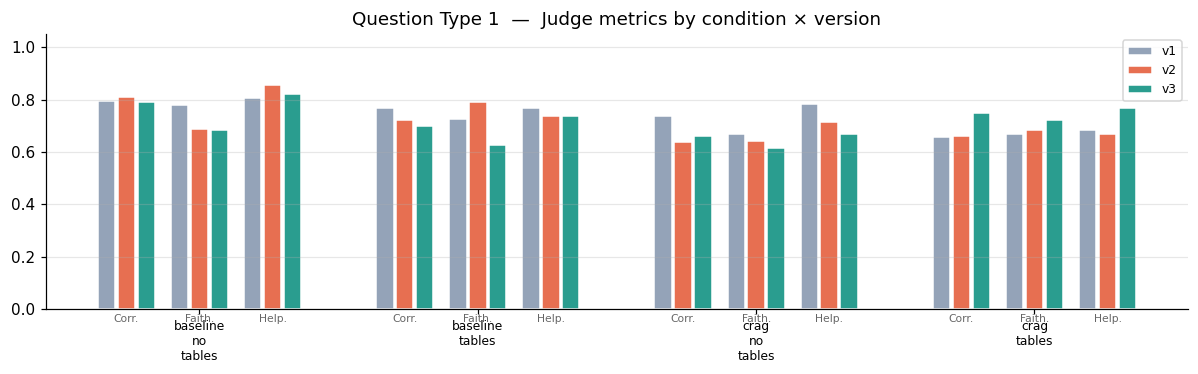

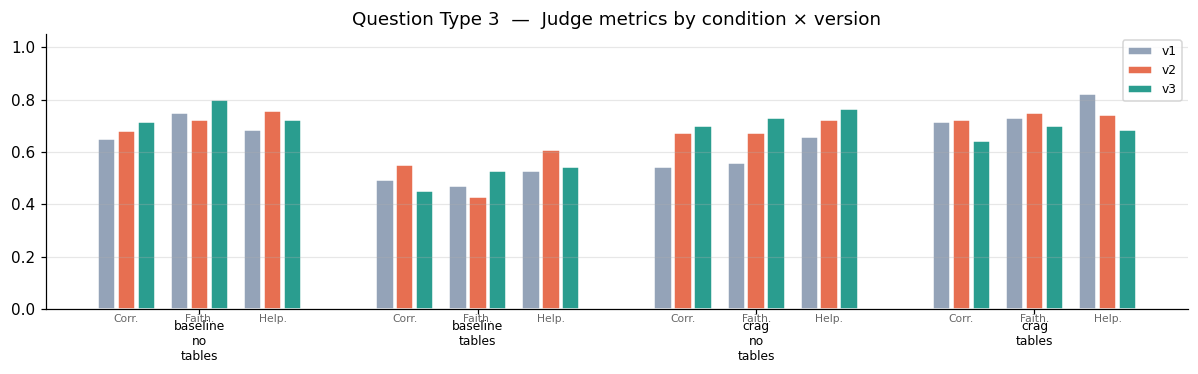

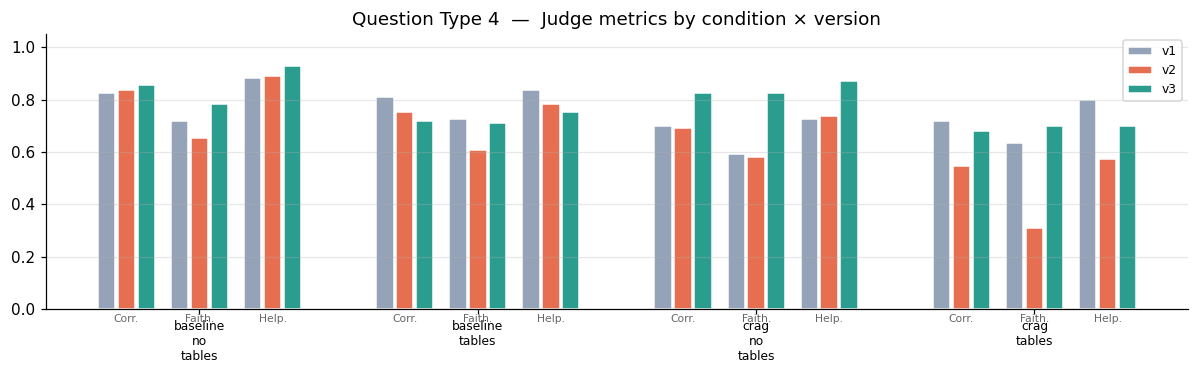

In [12]:
judge_metrics = ['judge_correctness', 'judge_faithfulness', 'judge_helpfulness']
judge_labels = ['Corr.', 'Faith.', 'Help.']
if all('judge_correctness' in df.columns for df in dfs.values()):
    for qt in sorted(dfs['v3']['question_type'].unique()):
        fig, ax = plt.subplots(figsize=(11, 3.5))
        x = np.arange(len(CONDITIONS))
        width = 0.25
        for i, m in enumerate(judge_metrics):
            for j, v in enumerate(VERSIONS):
                df = dfs[v]
                vals = []
                for c in CONDITIONS:
                    sub = df[(df['condition']==c) & (df['question_type']==qt)]
                    vals.append(sub[m].mean() if m in sub.columns and len(sub) else float('nan'))
                offset = (i - 1) * (width * 1.05)
                bar_x = x + offset
                color = ['#94A3B8', '#E76F51', '#2A9D8F'][j]
                bar_pos_x = bar_x + (j - 1) * (width / 3.5)
                ax.bar(bar_pos_x, vals, width / 4, color=color, edgecolor='white',
                       label=v if i == 0 else None)
        ax.set_xticks(x)
        ax.set_xticklabels([c.replace('_', '\n') for c in CONDITIONS], fontsize=8)
        for xi in x:
            for i, lbl in enumerate(judge_labels):
                offset = (i - 1) * (width * 1.05)
                ax.text(xi + offset, -0.05, lbl, ha='center', fontsize=7, color='#666')
        ax.set_ylim(0, 1.05)
        ax.set_title(f'Question Type {qt}  —  Judge metrics by condition × version')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

## 9. Edge-case category drill-down (CRAG conditions only, v3)

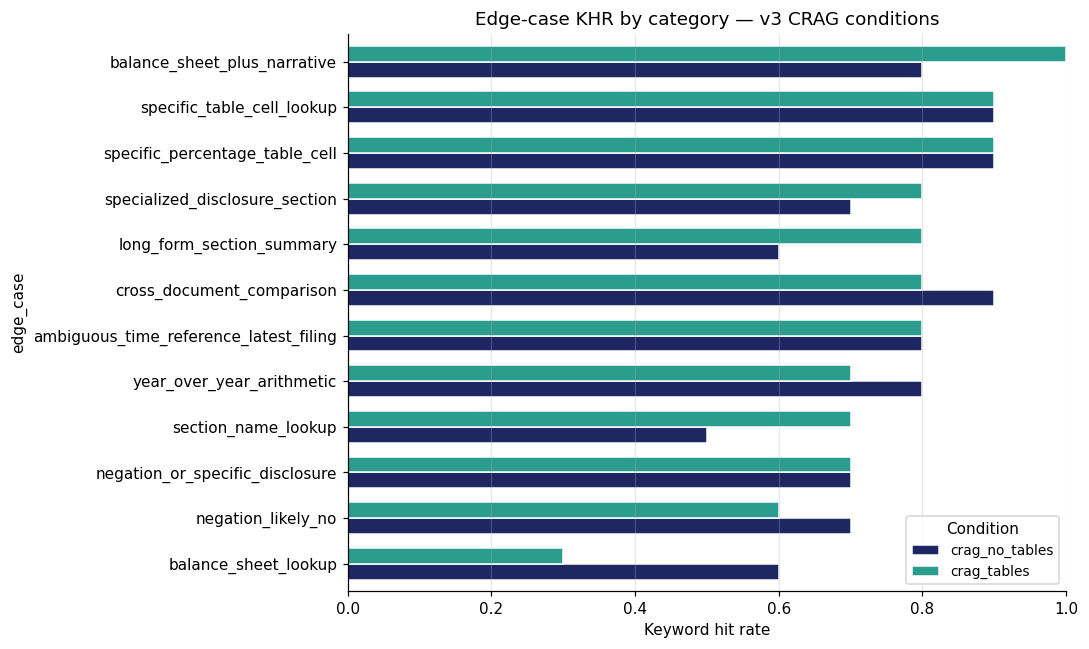

In [13]:
v3 = dfs.get('v3')
if v3 is not None and 'edge_case' in v3.columns:
    ec = v3[v3['condition'].astype(str).str.startswith('crag') & 
           v3['edge_case'].astype(str).ne('') & 
           v3['edge_case'].notna()]
    if len(ec):
        pivot = ec.groupby(['condition','edge_case'])['keyword_hit_rate'].mean().unstack().T.round(3)
        pivot = pivot.sort_values(by='crag_tables', ascending=True)
        fig, ax = plt.subplots(figsize=(10, 6))
        pivot.plot(kind='barh', ax=ax, color=['#1E2761', '#2A9D8F'], edgecolor='white', width=0.7)
        ax.set_title('Edge-case KHR by category — v3 CRAG conditions')
        ax.set_xlabel('Keyword hit rate')
        ax.set_xlim(0, 1)
        ax.legend(title='Condition', loc='lower right', fontsize=9)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

## Latency analysis

### Mean latency per condition × version with bootstrap 95% CI

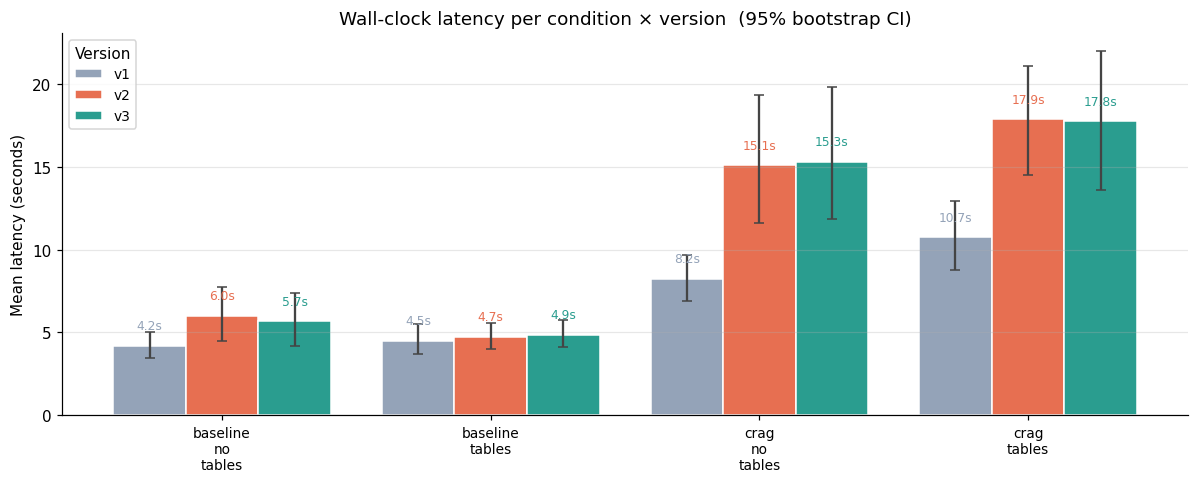

In [17]:
def bootstrap_mean_ci(values, n_resamples=1000, seed=RNG_SEED):
    arr = np.asarray([v for v in values if v is not None and not (isinstance(v, float) and np.isnan(v))])
    if len(arr) == 0:
        return float('nan'), float('nan'), float('nan')
    rng = np.random.default_rng(seed=seed)
    boot = [rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_resamples)]
    return float(arr.mean()), float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(CONDITIONS))
width = 0.27
for j, v in enumerate(VERSIONS):
    df = dfs[v]
    means, errs_lo, errs_hi = [], [], []
    for cond in CONDITIONS:
        sub = df[df['condition'] == cond]
        m, lo, hi = bootstrap_mean_ci(sub['latency_ms'])
        means.append(m / 1000)
        errs_lo.append((m - lo) / 1000)
        errs_hi.append((hi - m) / 1000)
    color = ['#94A3B8', '#E76F51', '#2A9D8F'][j]
    bar_x = x + (j - 1) * width
    ax.bar(bar_x, means, width, color=color, edgecolor='white', label=v,
           yerr=[errs_lo, errs_hi], capsize=3, ecolor='#444')
    for xi, m in zip(bar_x, means):
        ax.text(xi, m + 1, f'{m:.1f}s', ha='center', fontsize=8, color=color)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in CONDITIONS], fontsize=9)
ax.set_ylabel('Mean latency (seconds)')
ax.set_title('Wall-clock latency per condition × version  (95% bootstrap CI)')
ax.legend(title='Version', loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 10b. Latency distribution per condition

/var/folders/dz/ykmlvvnx7gg2p91fhyn9gn600000gn/T/ipykernel_70957/2459976231.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_cond, labels=[c.replace('_', '\n') for c in CONDITIONS],
/var/folders/dz/ykmlvvnx7gg2p91fhyn9gn600000gn/T/ipykernel_70957/2459976231.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_cond, labels=[c.replace('_', '\n') for c in CONDITIONS],
/var/folders/dz/ykmlvvnx7gg2p91fhyn9gn600000gn/T/ipykernel_70957/2459976231.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_cond, labels=[c.replace('_', '\n') for c in CONDITIO

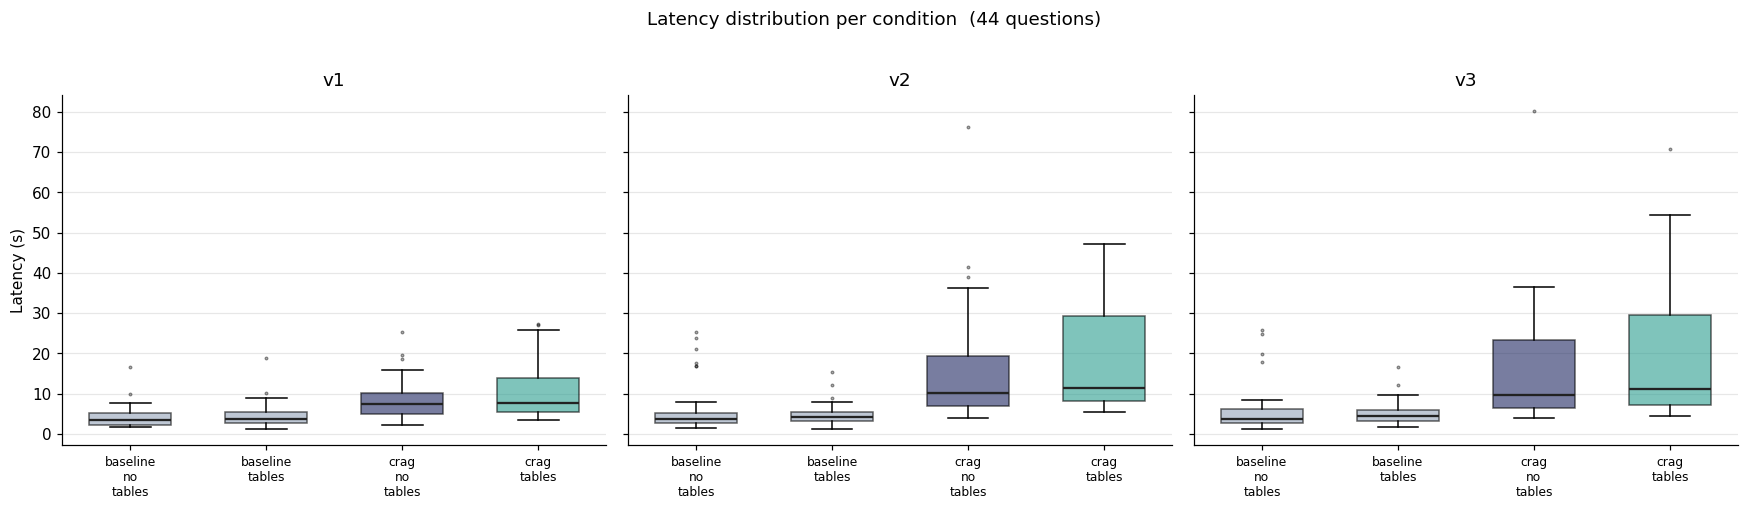

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (v_label, df) in zip(axes, dfs.items()):
    data_per_cond = [df[df['condition'] == c]['latency_ms'].dropna() / 1000 for c in CONDITIONS]
    bp = ax.boxplot(data_per_cond, labels=[c.replace('_', '\n') for c in CONDITIONS],
                    patch_artist=True, widths=0.6,
                    medianprops=dict(color='#222', linewidth=1.5),
                    flierprops=dict(marker='.', markersize=3, alpha=0.5))
    for patch, color in zip(bp['boxes'],
                            ['#94A3B8', '#94A3B8', '#1E2761', '#2A9D8F']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(f'{v_label}')
    ax.set_ylabel('Latency (s)' if ax is axes[0] else '')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Latency distribution per condition  (44 questions)', y=1.02)
plt.tight_layout()
plt.show()

### KHR vs latency

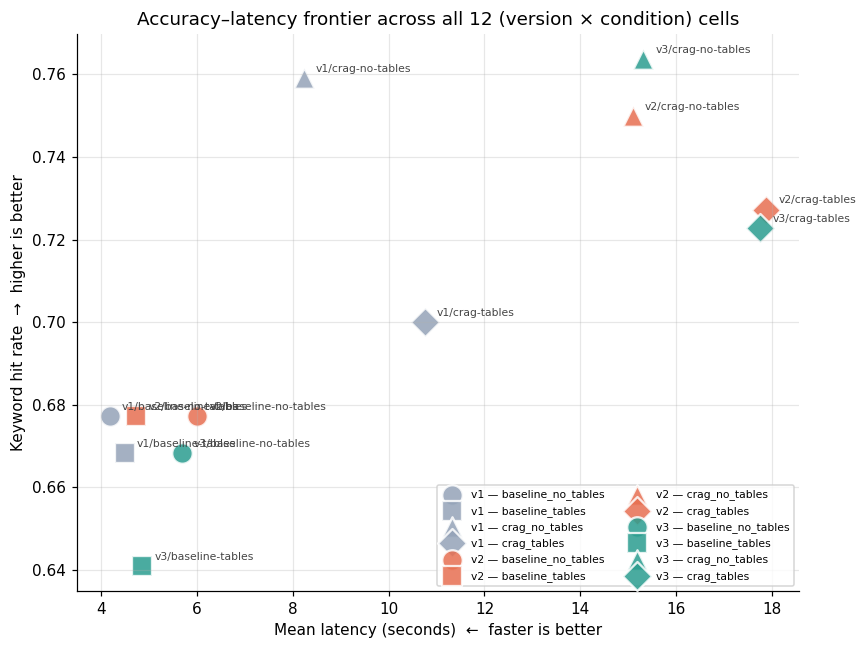

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
version_colors = {'v1': '#94A3B8', 'v2': '#E76F51', 'v3': '#2A9D8F'}
marker = {'baseline_no_tables': 'o', 'baseline_tables': 's', 'crag_no_tables': '^', 'crag_tables': 'D'}
for v, df in dfs.items():
    for cond in CONDITIONS:
        sub = df[df['condition'] == cond]
        khr = sub['keyword_hit_rate'].mean()
        lat = sub['latency_ms'].mean() / 1000
        ax.scatter(lat, khr, color=version_colors[v], marker=marker[cond],
                   s=180, edgecolor='white', linewidth=1.5, alpha=0.85,
                   label=f'{v} — {cond}')
        ax.annotate(f'{v}/{cond.replace("_", "-")}', (lat, khr),
                    textcoords='offset points', xytext=(8, 4), fontsize=7, color='#444')
ax.set_xlabel('Mean latency (seconds)  ←  faster is better')
ax.set_ylabel('Keyword hit rate  →  higher is better')
ax.set_title('Accuracy–latency frontier across all 12 (version × condition) cells')
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

### Per-question-type latency

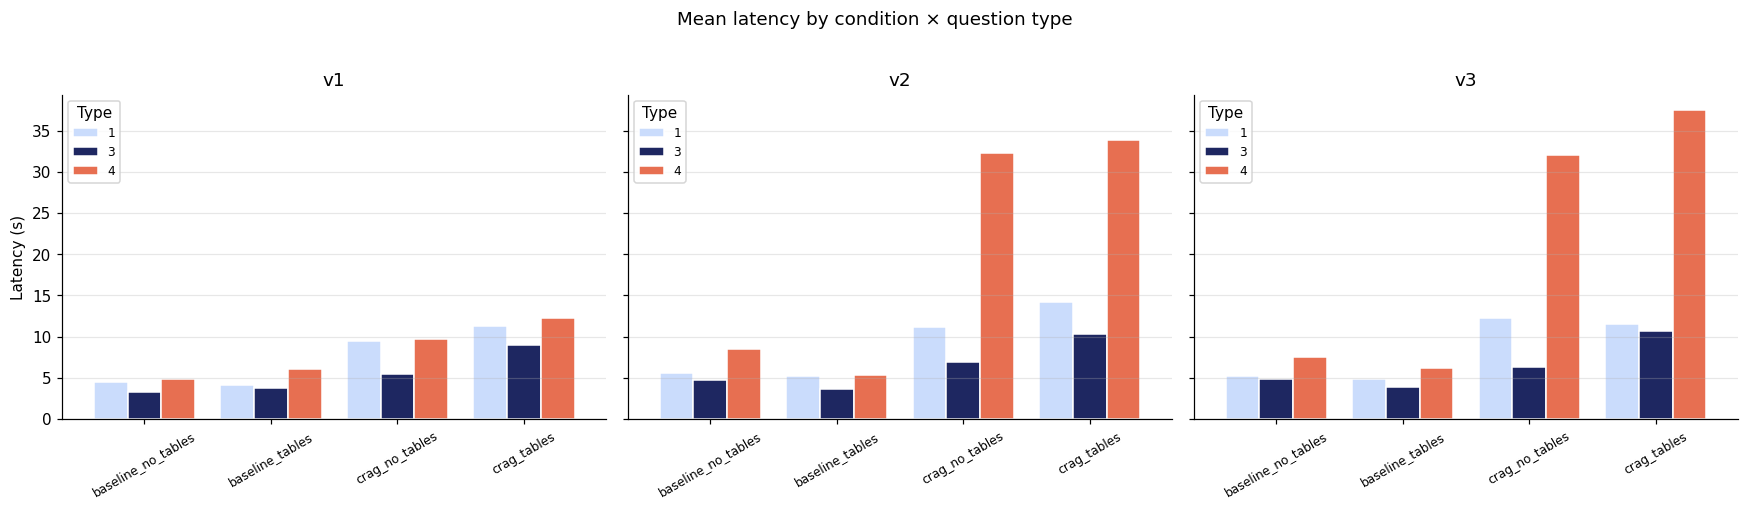

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
type_colors = {1: '#CADCFC', 3: '#1E2761', 4: '#E76F51'}
for ax, (v_label, df) in zip(axes, dfs.items()):
    pivot = df.groupby(['condition', 'question_type'])['latency_ms'].mean().unstack() / 1000
    pivot = pivot.reindex(CONDITIONS)
    pivot.plot(kind='bar', ax=ax, color=[type_colors.get(c, '#999') for c in pivot.columns],
               edgecolor='white', width=0.8)
    ax.set_title(f'{v_label}')
    ax.set_ylabel('Latency (s)' if ax is axes[0] else '')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(title='Type', fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Mean latency by condition × question type', y=1.02)
plt.tight_layout()
plt.show()

### Did the web suppression save time?

In [20]:
if 'v2' in dfs and 'v3' in dfs:
    rows = []
    for cond in CONDITIONS:
        a = dfs['v2'][dfs['v2']['condition'] == cond][['question_id', 'latency_ms']].rename(columns={'latency_ms': 'v2'})
        b = dfs['v3'][dfs['v3']['condition'] == cond][['question_id', 'latency_ms']].rename(columns={'latency_ms': 'v3'})
        merged = a.merge(b, on='question_id').dropna()
        for qt_label in ['Overall'] + sorted(dfs['v3']['question_type'].dropna().unique().tolist()):
            if qt_label == 'Overall':
                diffs = (merged['v3'] - merged['v2']).values / 1000
            else:
                ids_for_type = dfs['v3'][dfs['v3']['question_type']==qt_label]['question_id'].unique()
                sub = merged[merged['question_id'].isin(ids_for_type)]
                if not len(sub):
                    continue
                diffs = (sub['v3'] - sub['v2']).values / 1000
            mean_d = float(np.mean(diffs))
            rng = np.random.default_rng(seed=RNG_SEED)
            boot = [rng.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(1000)]
            lo, hi = np.quantile(boot, [0.025, 0.975])
            sig = '✓' if (lo > 0 or hi < 0) else '~'
            rows.append({'condition': cond, 'question_type': qt_label,
                         'Δ_latency_s': mean_d, 'CI_lo': lo, 'CI_hi': hi,
                         'CI_excl_0': sig, 'n': len(diffs)})
    print('=== v3 − v2 latency deltas (seconds, per-row matched) ===')
    print('   negative = v3 is faster; positive = v3 is slower\n')
    print(pd.DataFrame(rows).to_string(index=False, float_format='{:+.2f}'.format))

=== v3 − v2 latency deltas (seconds, per-row matched) ===
   negative = v3 is faster; positive = v3 is slower

         condition question_type  Δ_latency_s  CI_lo  CI_hi CI_excl_0  n
baseline_no_tables       Overall        -0.32  -1.33  +0.66         ~ 44
baseline_no_tables             1        -0.33  -2.32  +1.48         ~ 19
baseline_no_tables             3        +0.16  -0.51  +0.89         ~ 14
baseline_no_tables             4        -0.92  -3.01  +0.48         ~ 11
   baseline_tables       Overall        +0.13  -0.51  +0.86         ~ 44
   baseline_tables             1        -0.42  -1.57  +0.59         ~ 19
   baseline_tables             3        +0.24  -0.16  +0.66         ~ 14
   baseline_tables             4        +0.94  -0.49  +2.96         ~ 11
    crag_no_tables       Overall        +0.22  -1.45  +1.92         ~ 44
    crag_no_tables             1        +1.12  -0.08  +2.55         ~ 19
    crag_no_tables             3        -0.65  -2.32  +0.51         ~ 14
    crag_no_t

## 11. Summary takeaways for the report

In [24]:
if 'v2' in dfs and 'v3' in dfs:
    print('=== Auto-summarized headline takeaways ===\n')
    delta_v3v2 = deltas_between('v2', 'v3', dfs)
    biggest_wins = delta_v3v2.stack().nlargest(3)
    biggest_losses = delta_v3v2.stack().nsmallest(3)
    print('Biggest v3 wins (over v2) — (condition, metric):')
    for (cond, metric), val in biggest_wins.items():
        print(f'  {cond:25s}  {metric:15s}  {val:+.3f}')
    print()
    print('Biggest v3 regressions (vs v2):')
    for (cond, metric), val in biggest_losses.items():
        print(f'  {cond:25s}  {metric:15s}  {val:+.3f}')
    print()
    monotonic_count = 0
    total = 0
    for cond in CONDITIONS:
        for m in METRIC_COLS:
            try:
                vals = [dfs[v][dfs[v]['condition']==cond][m].mean() for v in VERSIONS]
                total += 1
                if vals[0] <= vals[1] <= vals[2]:
                    monotonic_count += 1
            except Exception:
                pass
    print(f'Monotonic improvement check: {monotonic_count}/{total} cells improve monotonically v1→v2→v3.')
    print('Non-monotonic cells are where v2 regressed and v3 recovered (or vice versa) — the most interesting story for the report.')
    print()
    # Latency summary
    print('=== Latency summary (mean seconds per condition × version) ===')
    for v, df in dfs.items():
        means = df.groupby('condition')['latency_ms'].mean() / 1000
        print(f'  {v}:  ' + '  '.join([f'{c[:6]}={means[c]:.1f}s' for c in CONDITIONS if c in means.index]))

=== Auto-summarized headline takeaways ===

Biggest v3 wins (over v2) — (condition, metric):
  crag_tables                Faithfulness     +0.098
  crag_no_tables             Faithfulness     +0.068
  crag_tables                Helpfulness      +0.057

Biggest v3 regressions (vs v2):
  baseline_tables            Correctness      -0.050
  baseline_tables            KHR              -0.036
  baseline_tables            Helpfulness      -0.027

Monotonic improvement check: 2/16 cells improve monotonically v1→v2→v3.
Non-monotonic cells are where v2 regressed and v3 recovered (or vice versa) — the most interesting story for the report.

=== Latency summary (mean seconds per condition × version) ===
  v1:  baseli=4.2s  baseli=4.5s  crag_n=8.2s  crag_t=10.7s
  v2:  baseli=6.0s  baseli=4.7s  crag_n=15.1s  crag_t=17.9s
  v3:  baseli=5.7s  baseli=4.9s  crag_n=15.3s  crag_t=17.8s
